<a href="https://colab.research.google.com/github/25ds3000042/GPU_Programming_Fundamentals_with_CUDA/blob/main/Julia_set/Julia_Set_using_CUDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#pip install numba

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda

In [3]:
# CUDA kernel
@cuda.jit
def julia_kernel(image, c_real, c_imag, max_iter):

    # Which pixel does this thread handle?
    x = cuda.blockIdx.x * cuda.blockDim.x + cuda.threadIdx.x
    y = cuda.blockIdx.y * cuda.blockDim.y + cuda.threadIdx.y

    height = image.shape[0]
    width = image.shape[1]

    # Make sure thread is inside image
    if x < width and y < height:

        # Convert pixel → complex number
        zx = (x - width / 2) * 4 / width
        zy = (y - height / 2) * 3 / height

        # Julia Set calculation
        for i in range(max_iter):

            # z² = (zx + zy*i)²
            zx_new = zx * zx - zy * zy + c_real
            zy_new = 2 * zx * zy + c_imag

            zx = zx_new
            zy = zy_new

            # Check if number escapes
            if zx * zx + zy * zy > 4:
                break

        image[y, x] = i

In [4]:
# Image dimensions
width = 800
height = 600

image = np.zeros((height, width), dtype=np.uint32)

In [5]:
# Julia constant
c_real = -0.7
c_imag = 0.27015

max_iter = 300

 CUDA configuration

In [6]:
threads_per_block = (16, 16)

blocks_x = (width + threads_per_block[0] - 1) // threads_per_block[0]
blocks_y = (height + threads_per_block[1] - 1) // threads_per_block[1]

blocks_per_grid = (blocks_x, blocks_y)

In [7]:
# Copy image to GPU
d_image = cuda.to_device(image)

In [8]:
# Run CUDA kernel
julia_kernel[blocks_per_grid, threads_per_block](
    d_image,
    c_real,
    c_imag,
    max_iter
)

In [9]:
# Copy result back to CPU
image = d_image.copy_to_host()

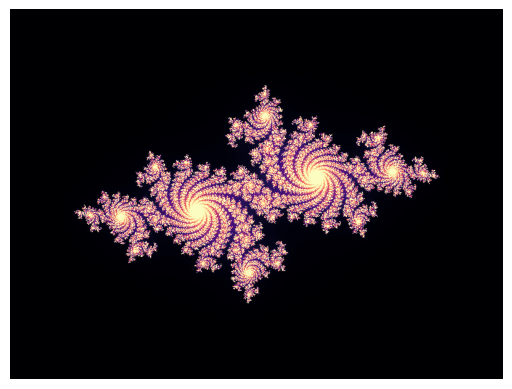

In [10]:
# Display
plt.imshow(image, cmap="magma")
plt.axis("off")
plt.show()